# AutoKnots: Adaptive Spline Compression for Quantum Control Signals

**Faithful implementation of Vitenti et al. (2024), arXiv:2412.13423**
with optimizations for our relevant waveforms

---

## Mathematical Foundation

### Cubic spline with not-a-knot boundary conditions

Given knots $x_0 < x_1 < \cdots < x_n$ and values $f(x_i)$, a cubic spline
$\hat{f}(x)$ is a piecewise cubic satisfying C0, C1, C2 continuity at all knots.

**Why not-a-knot, not natural?**
Natural BCs fix $\hat{f}''(x_0) = \hat{f}''(x_n) = 0$. When the true
$f'' \neq 0$ at a boundary, natural splines degrade to $O(h^2)$ accuracy
near the endpoints — two orders of magnitude worse than the $O(h^4)$ interior rate.
Not-a-knot enforces continuity of $\hat{f}'''$ at the second and second-to-last
knots, achieving $O(h^4)$ *everywhere* with no boundary derivative information needed.
This is scipy's default and is what the AutoKnots paper uses.

### The two convergence conditions (Vitenti et al., eqs. 2.8a and 2.8b)

For interval $i$ with left/right knots $x_i, x_{i+1}$, width $h_i = x_{i+1} - x_i$,
and midpoint $\bar{x}_i = (x_i + x_{i+1})/2$:

**Condition 2.8a — pointwise error at midpoint:**
$$|f(\bar{x}_i) - \hat{f}(\bar{x}_i)| < \delta\bigl[|f(\bar{x}_i)| + \varepsilon\bigr]$$

In English, this is saying that the error inthe midpoint must be less than $\delta$ times the signal value at that point (with some $\varepsilon$ floor that comes from the LSB of our DAC).


**Condition 2.8b — integral consistency:**
$$\left|\tilde{I}_i - \hat{I}_i\right| < \delta\bigl[|\tilde{I}_i| + \varepsilon h_i\bigr]$$

Does the spline integrate to the same value at the true signal over the interval? For the integral of the true signal, we don't have a formula, so we use Simpson's rule to estimate it, and for the spline integral, we use the closed form analytic solution for a cubic polynomial. 

where:
- $\tilde{I}_i = \frac{h_i}{6}\bigl[f(x_i) + 4f(\bar{x}_i) + f(x_{i+1})\bigr]$
  is Simpson's 1/3 rule applied to the TRUE signal
- $\hat{I}_i = \int_{x_i}^{x_{i+1}} \hat{f}(x)\,dx$ is the EXACT analytic
  integral of the cubic spline segment (computed via Horner's method, no quadrature)

**Why two conditions?** Both scale as $\sim |f^{(4)}|_i h_i^4$, but with
different proportionality constants ($1/384$ for pointwise, $1/192$ for integral).
They catch each other's blind spots. For our use case, condition 2.8b directly bounds
the pulse area error, which controls the gate rotation angle.

### Subdivision rule (Algorithm 1 of the paper)

Each interval carries a counter $s_i \in \{0, 1\}$ (s_conv = 1).
At each iteration, for every interval with $s_i = 0$:
1. Insert midpoint $\bar{x}_i$ as a new permanent knot (with value $f(\bar{x}_i)$)
2. Refit the full spline on the enlarged knot set
3. Check both conditions on the two child intervals
4. If both pass: $s = 1$. Otherwise: $s = 0$ (will subdivide again).

All evaluations of $f$ become permanent knots — nothing is wasted.

### Error scaling and knot density

Required interval width to hit error $\delta$:
$$h_i \sim \left(\frac{384\,\delta}{|f^{(4)}|_i}\right)^{1/4}$$

So $K \propto \delta^{-1/4}$ for smooth signals — the algorithm automatically
places knots where $|f^{(4)}|$ is large (fast oscillation) and spreads them
where it is small (slow variation), without ever computing $f^{(4)}$ directly.

### The refine option (Section 2.5)

A sharp feature fully inside a wide interval can be missed: its midpoint
may land on the flat part, pass both conditions, and the feature is skipped.
After convergence, we flag intervals wider than $\text{mean}(h) + r\cdot\text{std}(h)$
and force their subdivision. This is directly relevant to DRAG transients,
SPAM edges, and any pulse onset that sits inside a wider gate structure.

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, interp1d
from scipy.signal import chirp as scipy_chirp
from dataclasses import dataclass, field
from typing import Callable, Optional
import warnings

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})

## Analytic spline segment integral (exact, O(n))

scipy stores polynomail coefficients as `cs.c[k, i]` = coefficient of
$(x - x_i)^{3-k}$, i.e., `cs.c[0]=d, cs.c[1]=c, cs.c[2]=b, cs.c[3]=a` where:
$$S_i(u) = d u^3 + c u^2 + b u + a, \quad u = x - x_i$$

Speeficially, each segment $S_i$ will cover one interval, and can be described by a cubic polynomial, so with n segments, it's stored such that `cs.c.shape` is (4,n) for a cubic polynomial

Exact integral over $[x_i, x_{i+1}]$ (width $h_i$), via Horner form:
$$\hat{I}_i = h_i\!\left(a + h_i\!\left(\frac{b}{2} + h_i\!\left(\frac{c}{3}
  + h_i \frac{d}{4}\right)\right)\right)$$

In [78]:
def spline_integrals(cs: CubicSpline) -> np.ndarray:
    """Exact analytic integral of each segment of a CubicSpline (pp-form)."""
    h = np.diff(cs.x)
    d, c, b, a = cs.c[0], cs.c[1], cs.c[2], cs.c[3]
    return h * (a + h * (b / 2.0 + h * (c / 3.0 + h * d / 4.0)))

## Vectorized convergence check

**Critical implementation note:** the TRUE signal values $f(x_i)$ and $f(x_{i+1})$
must enter the Simpson's rule estimate — not the spline values (which are trivially
equal to $f$ at knots by construction and would make condition 2.8b meaningless).
We track `f_at_knots` separately as the ground-truth values.

In [82]:
def check_conditions(
    cs: CubicSpline,
    f_at_knots: np.ndarray,    # TRUE f at knot locations, shape (n+1,)
    f_at_mids:  np.ndarray,    # TRUE f at interval midpoints, shape (n,)
    delta: float,
    eps:   float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Check AutoKnots conditions (2.8a) and (2.8b) for all intervals simultaneously.

    Returns
    -------
    pass_f  : 2.8a passed per interval
    pass_I  : 2.8b passed per interval
    passed  : both passed per interval (the convergence criterion)
    """
    h = np.diff(cs.x)
    x_mids = 0.5 * (cs.x[:-1] + cs.x[1:])

    # --- Condition 2.8a ---
    fhat_mids = cs(x_mids)
    err_f = np.abs(f_at_mids - fhat_mids)
    pass_f = err_f < delta * (np.abs(f_at_mids) + eps)

    # --- Condition 2.8b ---
    # Simpson uses TRUE f values at knots and midpoints
    I_simp = (h / 6.0) * (f_at_knots[:-1] + 4.0 * f_at_mids + f_at_knots[1:])
    I_spl  = spline_integrals(cs)
    err_I  = np.abs(I_simp - I_spl)
    pass_I = err_I < delta * (np.abs(I_simp) + eps * h)

    return pass_f, pass_I, pass_f & pass_I

## AutoKnots result container

In [84]:
@dataclass
class AutoKnotsResult:
    spline:        CubicSpline
    knots:         np.ndarray   # final knot times
    f_at_knots:    np.ndarray   # true f values at knots
    converged:     bool
    n_iterations:  int
    n_refine_passes: int
    history: list = field(default_factory=list)  # (n_knots, n_fail, maxF, maxI)

    @property
    def n_knots(self):    return len(self.knots)
    @property
    def n_segments(self): return len(self.knots) - 1

    def evaluate(self, t: np.ndarray) -> np.ndarray:
        return self.spline(np.asarray(t, dtype=float))

    def ppform(self) -> dict:
        """
        piecewise polynomial-form representation for hardware upload.

        cs.c has shape (4, n): each column i gives [d,c,b,a] such that
            S_i(t) = d*(t-ti)^3 + c*(t-ti)^2 + b*(t-ti) + a

        One 32-byte word per segment (4 × float64) 
        """
        return {
            'breakpoints':  self.spline.x,       # shape (K,)
            'coefficients': self.spline.c,        # shape (4, K-1)
            'n_knots':      self.n_knots,
            'n_segments':   self.n_segments,
            'ddr_bytes':    self.n_segments * 32,
        }

## The AutoKnots algorithm

In [ ]:
def autoknots(
    f_func:   Callable,
    t_start:  float,
    t_end:    float,
    delta:    float = 1e-3,
    eps:      float = 0.0,
    n_init:   int   = 6,
    max_knots: int  = 4096,
    min_dt:   float = 0.0,
    refine:   bool  = True,
    refine_ns: float = 5.0,
    refine_max_passes: int = 3,
    verbose:  bool  = True,
) -> AutoKnotsResult:
    """
    AutoKnots: adaptive cubic spline knot allocation.

    Parameters
    ----------
    f_func    : callable, f(t_array) -> array_like. The function to approximate.
                Must accept a numpy array of times and return a numpy array of values.
    t_start   : left endpoint of time
    t_end     : right endpoint of time
    delta     : relative tolerance δ. Primary parameter. Directly affects knot count and spline expressiveness
                Typical range: 1e-2 (coarse) to 1e-5 (tight).
    eps       : scale parameter ε.
                Set eps=0 for positive-definite functions (paper's default).
                For signals that cross or approach zero: set eps to ~1% of peak
                amplitude so relative error stays finite near zero crossings.
                Too large an eps causes under-sampling; too small causes over-sampling
                in near-zero regions. THIS IS ALSO KEY

    n_init    : number of initial uniformly-spaced knots (minimum 6 for not-a-knot).
    max_knots : safety cap. If the algorithm would exceed this, it stops with a warning.
    min_dt    : minimum allowed spacing between adjacent knots (seconds).
                Motivated by the time-axis DAC resolution: with a 14-bit timestamp DAC
                over a span T, adjacent knots closer than T/2^14 collapse onto the
                same hardware time word and cannot be resolved. An interval is only
                subdivided if its width h_i >= 2*min_dt (so both children remain >= min_dt).
                Intervals that still fail the error conditions but are already at the
                floor are frozen and reported via a single warning. Set min_dt=0 (default)
                to disable. Typical: min_dt = (t_end - t_start) / 2**14.
    refine    : enable plateau/hidden-feature refinement
                Recommended when signal has flat regions with nearby sharp features.
    refine_ns : sensitivity parameter r in eq. (2.14). Default 5 (from paper).
                Lower values (3-4) flag more intervals; use for very spiky signals.
    refine_max_passes : maximum number of refine-then-reconverge cycles.
    verbose   : print iteration table.

    Returns
    -------
    AutoKnotsResult
    """
    assert n_init >= 6,  "not-a-knot requires at least 6 initial knots"
    assert delta > 0,    "delta must be positive"
    assert eps >= 0,     "eps must be non-negative"
    assert min_dt >= 0,  "min_dt must be non-negative"

    history          = []
    n_refine_passes  = 0
    converged        = False

    # ── inner adaptive subdivision loop ──────────────────────────────────────
    def _loop(t_k: np.ndarray, f_k: np.ndarray, tag: str = "") -> tuple:
        """
        Subdivide failing intervals until all pass both conditions, subject to
        the min_dt floor on interval width.

        t_k : current knot times, shape (K,), strictly increasing
        f_k : TRUE signal values at t_k, shape (K,)
        """
        nonlocal converged

        if verbose:
            lbl = f" ({tag})" if tag else ""
            print(f"\n  ── AutoKnots loop{lbl} ──────────────────────────────")
            print(f"     δ={delta:.1e}  ε={eps:.1e}  min_dt={min_dt:.2e}  budget={max_knots}")
            print(f"  {'iter':>5} {'knots':>7} {'segs':>6} "
                  f"{'fail':>6} {'frozen':>7} {'maxF/δ':>10} {'maxI/δ':>10}")
            print(f"  {'·'*58}")

        frozen_reported = False

        for iteration in range(max_knots):
            cs = CubicSpline(t_k, f_k, bc_type='not-a-knot')

            # Evaluate TRUE function at interval midpoints
            x_mid = 0.5 * (t_k[:-1] + t_k[1:])
            f_mid = np.asarray(f_func(x_mid), dtype=float)

            # Both convergence conditions
            pass_f, pass_I, passed = check_conditions(cs, f_k, f_mid, delta, eps)
            n_fail = int(np.sum(~passed))

            # Diagnostics: normalise by δ so convergence is clear (target < 1)
            fhat_m = cs(x_mid)
            h      = np.diff(t_k)
            maxF   = float(np.max(np.abs(f_mid - fhat_m)
                                  / (np.abs(f_mid) + eps + 1e-300))) / delta
            I_s    = (h/6.0)*(f_k[:-1] + 4.0*f_mid + f_k[1:])
            I_spl  = spline_integrals(cs)
            maxI   = float(np.max(np.abs(I_s - I_spl)
                                  / (np.abs(I_s) + eps*h + 1e-300))) / delta

            # Intervals that fail but cannot be legally subdivided
            # (bisecting them would produce a child narrower than min_dt)
            too_narrow = h < 2.0 * min_dt if min_dt > 0 else np.zeros_like(h, dtype=bool)
            subdividable = ~passed & ~too_narrow
            frozen       = ~passed &  too_narrow
            n_frozen     = int(np.sum(frozen))
            n_sub        = int(np.sum(subdividable))

            history.append((len(t_k), n_fail, maxF, maxI))

            if verbose:
                print(f"  {iteration:>5} {len(t_k):>7} {len(t_k)-1:>6} "
                      f"{n_fail:>6} {n_frozen:>7} {maxF:>10.3e} {maxI:>10.3e}")

            # Convergence: either everything passes, OR every still-failing
            # interval is already at the min_dt floor (nothing more we can do).
            if n_fail == 0:
                converged = True
                if verbose:
                    print(f"\n  ✓ Converged in {iteration} iterations "
                          f"({len(t_k)} knots, {len(t_k)-1} segments)")
                return t_k, f_k, cs

            if n_sub == 0:
                # All failing intervals are frozen by min_dt.
                if not frozen_reported:
                    warnings.warn(
                        f"AutoKnots: {n_frozen} interval(s) hit the min_dt={min_dt:.3e} "
                        f"floor and cannot be subdivided further. "
                        f"Residual error may exceed δ on those intervals. "
                        f"Relax min_dt or increase delta to fix.",
                        RuntimeWarning
                    )
                    frozen_reported = True
                converged = True  # best we can do under the spacing constraint
                if verbose:
                    print(f"\n  ⚑ min_dt floor reached: {n_frozen} frozen interval(s); "
                          f"stopping ({len(t_k)} knots, {len(t_k)-1} segments)")
                return t_k, f_k, cs

            # Budget check BEFORE inserting
            if len(t_k) + n_sub > max_knots:
                warnings.warn(
                    f"AutoKnots: would exceed max_knots={max_knots} "
                    f"(need +{n_sub}, have {len(t_k)}). "
                    f"Stopping with {n_fail} failing intervals. "
                    f"Increase max_knots or relax delta.",
                    RuntimeWarning
                )
                return t_k, f_k, cs

            # ── Subdivide failing intervals that are wide enough ────────────
            # midpoints of subdividable intervals → new knots
            new_t = x_mid[subdividable]
            new_f = f_mid[subdividable]

            # Merge and sort
            t_all = np.concatenate([t_k, new_t])
            f_all = np.concatenate([f_k, new_f])
            idx   = np.argsort(t_all, kind='stable')
            t_k   = t_all[idx]
            f_k   = f_all[idx]

        # Exhausted iterations without convergence
        cs = CubicSpline(t_k, f_k, bc_type='not-a-knot')
        return t_k, f_k, cs

    # ── Initialise ───────────────────────────────────────────────────────────
    # If the requested n_init would already violate min_dt, back it off.
    span = t_end - t_start
    if min_dt > 0 and span / (n_init - 1) < min_dt:
        n_init = max(6, int(np.floor(span / min_dt)) + 1)
        if verbose:
            print(f"  [min_dt] reduced n_init to {n_init} to respect spacing floor")

    t_k = np.linspace(t_start, t_end, n_init)
    f_k = np.asarray(f_func(t_k), dtype=float)

    if verbose:
        print(f"\n{'═'*58}")
        print(f"  AutoKnots — Vitenti et al. (2024)")
        print(f"  [{t_start:.3e}, {t_end:.3e}]  δ={delta:.1e}  ε={eps:.1e}  min_dt={min_dt:.2e}")
        print(f"{'═'*58}")

    t_k, f_k, cs = _loop(t_k, f_k, tag="initial")

    # ── Refine pass (Section 2.5) ─────────────────────────────────────────────
    if refine and converged:
        for rp in range(refine_max_passes):
            h  = np.diff(t_k)
            th = np.mean(h) + refine_ns * np.std(h)
            # Only consider wide intervals that we are actually allowed to split
            wide = (h > th) & (h >= 2.0 * min_dt if min_dt > 0 else np.ones_like(h, dtype=bool))
            n_wide = int(np.sum(wide))

            if n_wide == 0:
                if verbose:
                    print(f"\n  Refine pass {rp+1}: no outlier intervals — done.")
                break

            if verbose:
                print(f"\n  Refine pass {rp+1}: forcing subdivision of "
                      f"{n_wide} wide intervals (threshold={th:.3e})")

            mid_t = 0.5 * (t_k[:-1][wide] + t_k[1:][wide])
            mid_f = np.asarray(f_func(mid_t), dtype=float)

            t_all = np.concatenate([t_k, mid_t])
            f_all = np.concatenate([f_k, mid_f])
            idx   = np.argsort(t_all, kind='stable')
            t_k   = t_all[idx]
            f_k   = f_all[idx]

            converged = False
            t_k, f_k, cs = _loop(t_k, f_k, tag=f"refine {rp+1}")
            n_refine_passes += 1

            if not converged:
                break

    if verbose:
        pp = (len(t_k)-1)*32
        min_h = float(np.min(np.diff(t_k)))
        print(f"\n{'═'*58}")
        print(f"  FINAL  {len(t_k)} knots | {len(t_k)-1} segs | "
              f"{pp} B ({pp/1024:.1f} kB) | min_h={min_h:.3e} | conv={converged}")
        print(f"{'═'*58}\n")

    return AutoKnotsResult(
        spline=cs, knots=t_k, f_at_knots=f_k,
        converged=converged,
        n_iterations=len(history),
        n_refine_passes=n_refine_passes,
        history=history,
    )

## Multi-channel compression with unified knot grid

All waveform channels (amplitude, frequency, phase, virtual phase)
share the same time axis.

We compress each channel independently, then take the union of all knot sets
and refit each channel on the unified grid.

Cost of union: typically 10-20% more knots than the most complex channel alone,
but the unified grid is always valid (more knots = more accurate, never less).

In [ ]:
def compress_multichannel(
    f_funcs:   dict,          # {'name': callable f(t)->array}
    t_start:   float,
    t_end:     float,
    delta:     float = 1e-3,
    eps:       float = 0.0,
    max_knots: int   = 4096,
    min_dt:    float = 0.0,
    refine:    bool  = True,
    refine_ns: float = 5.0,
    verbose:   bool  = True,
) -> dict:
    """
    Compress multiple waveform channels to a shared not-a-knot spline knot grid.
    Returns unified knots, per-channel splines, per-channel AutoKnotsResults,
    and pp-form info.

    min_dt enforces a minimum spacing on both per-channel fits AND on the
    unified grid: if the union of per-channel knot sets places two knots
    closer than min_dt, they are merged (the later one is dropped). This
    guarantees every segment on the unified grid is resolvable by a time-axis
    DAC whose LSB is min_dt.
    """
    all_knots = [np.linspace(t_start, t_end, 6)]
    per_ch = {}

    for name, f in f_funcs.items():
        if verbose:
            print(f"\n{'━'*58}")
            print(f"  Channel: {name}")
        res = autoknots(f, t_start, t_end,
                        delta=delta, eps=eps, max_knots=max_knots,
                        min_dt=min_dt,
                        refine=refine, refine_ns=refine_ns, verbose=verbose)
        per_ch[name] = res
        all_knots.append(res.knots)

    unified = np.unique(np.concatenate(all_knots))

    # Enforce min_dt on the unified grid: greedy left-to-right merge.
    # Endpoints are always kept; interior knots closer than min_dt to the last
    # kept knot are dropped.
    if min_dt > 0 and len(unified) > 2:
        kept = [unified[0]]
        for x in unified[1:-1]:
            if x - kept[-1] >= min_dt:
                kept.append(x)
        # Last endpoint: if it violates spacing with the previous kept knot,
        # drop that previous knot instead (we must keep t_end).
        if unified[-1] - kept[-1] < min_dt and len(kept) > 1:
            kept.pop()
        kept.append(unified[-1])
        n_dropped = len(unified) - len(kept)
        unified = np.asarray(kept)
        if verbose and n_dropped:
            print(f"\n  [min_dt] merged {n_dropped} unified knot(s) "
                  f"closer than {min_dt:.3e}")

    unified_splines = {}
    for name, f in f_funcs.items():
        f_u = np.asarray(f(unified), dtype=float)
        unified_splines[name] = CubicSpline(unified, f_u, bc_type='not-a-knot')

    n_segs = len(unified) - 1
    if verbose:
        imax = max(r.n_knots for r in per_ch.values())
        ov   = (len(unified)/imax - 1)*100
        print(f"\n{'━'*58}")
        print(f"  Unified: {len(unified)} knots "
              f"(max-individual: {imax}, overhead: {ov:.0f}%)")

    return {
        'knots':   unified,
        'splines': unified_splines,
        'results': per_ch,
        'ppform':  {
            'n_knots':   len(unified),
            'n_segments': n_segs,
            'n_channels': len(f_funcs),
            'ddr_bytes_per_channel': n_segs * 32,
            'total_ddr_bytes':       n_segs * 32 * len(f_funcs),
        }
    }

## Visualization

In [91]:
def plot_result(
    f_func:  Callable,
    t_plot:  np.ndarray,
    result:  AutoKnotsResult,
    delta:   float,
    eps:     float,
    title:   str = "AutoKnots",
    ylabel:  str = "amplitude",
):
    f_true   = np.asarray(f_func(t_plot), dtype=float)
    f_approx = result.evaluate(t_plot)
    residual = np.abs(f_true - f_approx)
    rel_err  = residual / (np.abs(f_true) + eps + 1e-300)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ax = axes[0, 0]
    ax.plot(t_plot*1e6, f_true,   'steelblue', lw=1.5, alpha=0.8, label='Signal')
    ax.plot(t_plot*1e6, f_approx, 'r--',       lw=1.5, alpha=0.9, label='Spline')
    ylim = ax.get_ylim()
    ax.vlines(result.knots*1e6, *ylim, colors='green', alpha=0.2, lw=0.7)
    ax.scatter(result.knots*1e6, result.f_at_knots, s=15, c='green', zorder=5)
    ax.set_ylim(ylim)
    ax.set_xlabel('Time (µs)'); ax.set_ylabel(ylabel)
    ax.set_title(f'{result.n_knots} knots · {result.n_segments} segments')
    ax.legend(fontsize=9)

    ax = axes[0, 1]
    ax.semilogy(t_plot*1e6, residual, 'steelblue', lw=0.8, alpha=0.8)
    peak = float(np.max(np.abs(f_true)))
    ax.axhline(delta*(peak+eps), color='red', ls='--', lw=1.5,
               label=f'δ·(peak+ε)={delta*(peak+eps):.2e}')
    ax.set_xlabel('Time (µs)'); ax.set_ylabel('|f − f̂|')
    ax.set_title('Absolute error'); ax.legend(fontsize=9)

    ax = axes[1, 0]
    ax.semilogy(t_plot*1e6, rel_err, 'purple', lw=0.8, alpha=0.8)
    ax.axhline(delta, color='red', ls='--', lw=1.5, label=f'δ = {delta:.1e}')
    ax.set_xlabel('Time (µs)'); ax.set_ylabel('|f−f̂|/(|f|+ε)')
    ax.set_title(f'Relative error — ε = {eps:.1e}'); ax.legend(fontsize=9)

    ax = axes[1, 1]
    if result.history:
        iters = np.arange(len(result.history))
        knts  = [h[0] for h in result.history]
        mF    = [h[2] for h in result.history]
        mI    = [h[3] for h in result.history]
        ax2   = ax.twinx()
        ax.plot(iters, knts, 'g-o', ms=4, lw=1.5, label='Knots')
        ax2.semilogy(iters, mF, 'b-s', ms=3, lw=1.2, alpha=0.8, label='MaxErr_f/δ')
        ax2.semilogy(iters, mI, 'r-^', ms=3, lw=1.2, alpha=0.8, label='MaxErr_I/δ')
        ax2.axhline(1.0, color='gray', ls=':', lw=1, label='δ threshold')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Knot count', color='green')
        ax2.set_ylabel('Relative error / δ')
        ax.set_title('Convergence history')
        l1, lb1 = ax.get_legend_handles_labels()
        l2, lb2 = ax2.get_legend_handles_labels()
        ax.legend(l1+l2, lb1+lb2, fontsize=8)

    plt.tight_layout()
    plt.show()

    pp = result.ppform()
    raw = len(t_plot) * 8
    print(f"  {result.n_knots} knots | {result.n_segments} segs | "
          f"{pp['ddr_bytes']} B ({pp['ddr_bytes']/1024:.1f} kB) | "
          f"{raw/pp['ddr_bytes']:.1f}× compression | "
          f"converged={result.converged}\n")

# Spline Compression for QubiC gates

These cells apply AutoKnots compression to the **actual pulses from
`qubitcfg.json`**

There are 2 envelope types this tries:
**DRAG** (`env_func: "DRAG"`) — single-qubit X90 gates:
- `twidth = 32 ns`, `sigmas = 3` → $\sigma = 32/(2 \times 3) \approx 5.33$ ns
- `delta = -268 MHz` 
- `alpha` — per-qubit DRAG coefficient 
- The pulse has I (Gaussian) and Q (scaled derivative) channels

**cos_edge_square** (`env_func: "cos_edge_square"`) — readout drive:
- `twidth = 2 µs`, `ramp_fraction = 0.25`
- 500 ns cosine ramp up → 1000 ns flat → 500 ns cosine ramp down


### Key finding from the compression benchmark

| Pulse | Raw samples | AutoKnots knots | Compression |
|---|---|---|---|
| DRAG X90 (I channel) | 32 | 23 | ~1.4× |
| DRAG X90 (Q channel) | 32 | 16–20 | ~1.6–2× |
| Readout cos_edge_square | 2000 | 41 | **48.8×** |

The X90 gates are already only 32 samples at 1 GSPS, so compression only gives
marginal benefit there. However, the readout pulse can compress well, since 2000 samples
→ 41 knots is a 48.8× reduction, with all 8 qubits using identical knot counts
(the shape is the same; only amplitude differs, which doesn't affect knot placement).

In [97]:
FS      = 1e9            # 1 GSPS DAC sample rate
DT      = 1 / FS         # 1 ns per sample
DAC_BITS = 16            # 16-bit I/Q envelope words
EPS_DAC  = 2 / (2**DAC_BITS)   # ~3.05e-5 — 1 DAC LSB, physically motivated eps floor


In [99]:
import os

cfg_path = 'qubitcfg.json' 

with open(cfg_path) as f:
    cfg = json.load(f)

# Extract X90 DRAG parameters for all qubits
drag_params = {}
for qn in ['Q0','Q1','Q2','Q3','Q4','Q5','Q6','Q7']:
    gate_key = f'{qn}X90'
    if gate_key in cfg['Gates']:
        pulse = cfg['Gates'][gate_key][0]
        p     = pulse['env'][0]['paradict']
        drag_params[qn] = {
            'alpha':  p['alpha'],
            'sigmas': p['sigmas'],
            'delta':  p['delta'],  
            'amp':    pulse['amp'],
            'twidth': pulse['twidth'],
        }

# Extract readout cos_edge_square amplitudes
read_params = {}
for qn in ['Q0','Q1','Q2','Q3','Q4','Q5','Q6','Q7']:
    gate_key = f'{qn}read'
    if gate_key in cfg['Gates']:
        pulse = cfg['Gates'][gate_key][0]
        read_params[qn] = {
            'amp':           pulse['amp'],
            'twidth':        pulse['twidth'],
            'ramp_fraction': pulse['env'][0]['paradict']['ramp_fraction'],
        }

print("Loaded DRAG X90 parameters:")
print(f"  {'Qubit':<6} {'alpha':>9} {'amp':>9} {'twidth':>10}  delta_MHz")
for qn, p in drag_params.items():
    print(f"  {qn:<6} {p['alpha']:>9.4f} {p['amp']:>9.5f} "
          f"{p['twidth']*1e9:>8.0f} ns  {p['delta']/1e6:.0f} MHz")

print(f"\nLoaded readout parameters:")
print(f"  {'Qubit':<6} {'amp':>9} {'twidth':>10}  ramp_frac")
for qn, p in read_params.items():
    print(f"  {qn:<6} {p['amp']:>9.5f} {p['twidth']*1e6:>8.1f} µs  "
          f"{p['ramp_fraction']}")

Loaded DRAG X90 parameters:
  Qubit      alpha       amp     twidth  delta_MHz
  Q0        0.5527   0.12755       32 ns  -268 MHz
  Q1        0.4508   0.18336       32 ns  -268 MHz
  Q2       -1.6428   0.20894       32 ns  -268 MHz
  Q3       -0.0036   0.23634       32 ns  -268 MHz
  Q4        0.5860   0.31095       32 ns  -268 MHz
  Q5        0.1348   0.39181       32 ns  -268 MHz
  Q6        3.0964   0.27321       32 ns  -268 MHz
  Q7       -1.7608   0.12159       32 ns  -268 MHz

Loaded readout parameters:
  Qubit        amp     twidth  ramp_frac
  Q0       0.24081      2.0 µs  0.25
  Q1       0.45736      2.0 µs  0.25
  Q2       0.68914      2.0 µs  0.25
  Q3       0.61842      2.0 µs  0.25
  Q4       0.60097      2.0 µs  0.25
  Q5       0.63934      2.0 µs  0.25
  Q6       0.45184      2.0 µs  0.25
  Q7       0.92467      2.0 µs  0.25


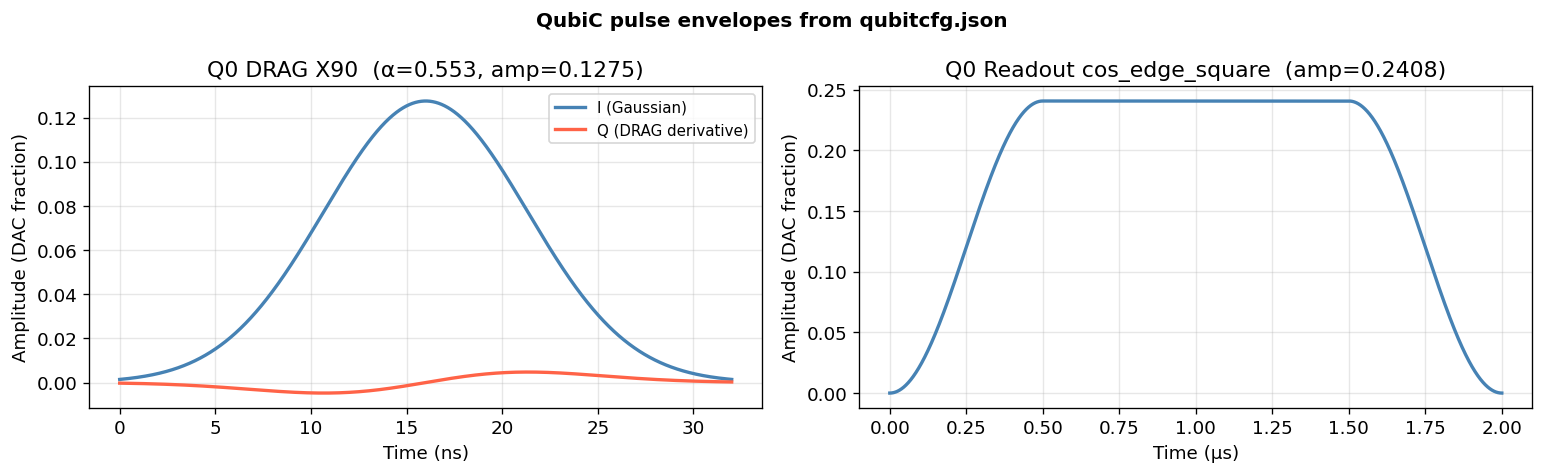

In [101]:
# ── Pulse envelope generators ────────────────────────────────────────────────

def make_drag(twidth, alpha, sigmas, delta_hz, amp, N=50_000):
    """
    QubiC DRAG envelope (env_func: 'DRAG').

    Parameters match qubitcfg.json exactly:
      twidth   : pulse duration (s)
      alpha    : DRAG coefficient
      sigmas   : number of sigma the Gaussian spans (twidth = 2*sigmas*sigma)
      delta_hz : anharmonicity in Hz (negative for transmons, e.g. -268e6)
      amp      : amplitude as fraction of DAC full scale
      N        : number of dense evaluation points

    Returns t, I, Q  (time array, in-phase, quadrature)

    The DRAG Q channel suppresses leakage to the |f> state (the second
    excited state of the transmon) by adding a correction proportional to
    the derivative of the Gaussian. The amplitude of Q is:
        Q_peak ~ amp * |alpha| / (|delta_hz * 2*pi| * sigma)
    For your parameters this is ~1-6% of the I amplitude.
    """
    t     = np.linspace(0, twidth, N)
    t_c   = twidth / 2
    sigma = twidth / (2 * sigmas)

    gauss = np.exp(-0.5 * ((t - t_c) / sigma)**2)
    dIdt  = -(t - t_c) / sigma**2 * gauss   # dGauss/dt (unnormalized)

    I = amp * gauss
    Q = amp * (alpha / (delta_hz * 2 * np.pi)) * dIdt
    return t, I, Q


def make_cos_edge_square(twidth, ramp_fraction, amp, N=50_000):
    """
    QubiC cosine-edge square pulse (env_func: 'cos_edge_square').

    Parameters match qubitcfg.json:
      twidth        : total pulse duration (s)
      ramp_fraction : fraction of total duration used for each ramp (0.25 = 25%)
      amp           : amplitude as fraction of DAC full scale

    Shape:
      [0, ramp_t)          : raised cosine ramp up  (0 → amp)
      [ramp_t, T-ramp_t]   : flat top               (amp)
      (T-ramp_t, T]        : raised cosine ramp down (amp → 0)

    where ramp_t = ramp_fraction * twidth.
    """
    t      = np.linspace(0, twidth, N)
    ramp_t = twidth * ramp_fraction
    env    = np.empty(N)

    rising  = t < ramp_t
    flat    = (t >= ramp_t) & (t <= twidth - ramp_t)
    falling = t > twidth - ramp_t

    env[rising]  = 0.5 * (1 - np.cos(np.pi * t[rising]  / ramp_t))
    env[flat]    = 1.0
    env[falling] = 0.5 * (1 + np.cos(np.pi * (t[falling] - (twidth - ramp_t)) / ramp_t))

    return t, amp * env

#Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("QubiC pulse envelopes from qubitcfg.json", fontsize=12, fontweight='bold')

# Q0 DRAG X90
p    = drag_params['Q0']
t, I, Q = make_drag(p['twidth'], p['alpha'], p['sigmas'], p['delta'], p['amp'])
ax = axes[0]
ax.plot(t*1e9, I, 'steelblue', lw=2, label='I (Gaussian)')
ax.plot(t*1e9, Q, 'tomato',    lw=2, label='Q (DRAG derivative)')
ax.set_xlabel('Time (ns)'); ax.set_ylabel('Amplitude (DAC fraction)')
ax.set_title(f'Q0 DRAG X90  (α={p["alpha"]:.3f}, amp={p["amp"]:.4f})')
ax.legend(fontsize=9)

# Q0 readout cos_edge_square
r      = read_params['Q0']
t_r, env = make_cos_edge_square(r['twidth'], r['ramp_fraction'], r['amp'])
ax = axes[1]
ax.plot(t_r*1e6, env, 'steelblue', lw=2)
ax.set_xlabel('Time (µs)'); ax.set_ylabel('Amplitude (DAC fraction)')
ax.set_title(f"Q0 Readout cos_edge_square  (amp={r['amp']:.4f})")

plt.tight_layout()
plt.show()

In [103]:
DELTA = 1e-3    # 0.1% relative tolerance — appropriate for 16-bit DAC
                # (DAC LSB = 3e-5, so 0.1% is ~3× above quantization noise)

drag_results  = {}
read_results  = {}

print("Compressing DRAG X90 pulses...")
print(f"{'Qubit':<6} {'Chan':>5} {'Knots':>7} {'Segs':>6} "
      f"{'DDR B':>8} {'MaxErr/δ':>10} {'Conv':>6}")
print("─" * 52)

for qn, p in drag_params.items():
    t_sig, I_sig, Q_sig = make_drag(
        p['twidth'], p['alpha'], p['sigmas'], p['delta'], p['amp']
    )
    drag_results[qn] = {}

    for ch_name, sig in [('I', I_sig), ('Q', Q_sig)]:
        # eps: floor at DAC LSB, but also at least 1% of channel peak
        # (handles near-zero Q channel for small alpha values)
        ch_peak = float(np.max(np.abs(sig)))
        eps     = max(EPS_DAC, 0.005 * ch_peak)

        fi = interp1d(t_sig, sig, kind='linear', fill_value='extrapolate')
        res = autoknots(fi, t_sig[0], t_sig[-1],
                        delta=DELTA, eps=eps,
                        refine=True, refine_ns=5.0, verbose=False)

        # measure actual max relative error
        f_hat = res.evaluate(t_sig)
        max_rel = float(np.max(np.abs(sig - f_hat) / (np.abs(sig) + eps))) / DELTA

        drag_results[qn][ch_name] = res
        print(f"{qn:<6} {ch_name:>5} {res.n_knots:>7} {res.n_segments:>6} "
              f"{res.n_segments*32:>8} {max_rel:>10.3f} "
              f"{'✓' if res.converged else '✗':>6}")

print()
print("Compressing Readout cos_edge_square pulses...")
print(f"{'Qubit':<6} {'Knots':>7} {'Segs':>6} {'DDR B':>8} "
      f"{'Raw samp':>10} {'Ratio':>8} {'Conv':>6}")
print("─" * 58)

for qn, p in read_params.items():
    t_sig, env_sig = make_cos_edge_square(p['twidth'], p['ramp_fraction'], p['amp'])
    env_peak = float(np.max(np.abs(env_sig)))
    eps      = max(EPS_DAC, 0.005 * env_peak)

    fi = interp1d(t_sig, env_sig, kind='linear', fill_value='extrapolate')
    res = autoknots(fi, t_sig[0], t_sig[-1],
                    delta=DELTA, eps=eps,
                    refine=True, refine_ns=5.0, verbose=False)

    raw   = int(p['twidth'] * FS)
    ratio = raw / res.n_knots
    read_results[qn] = res
    print(f"{qn:<6} {res.n_knots:>7} {res.n_segments:>6} "
          f"{res.n_segments*32:>8} {raw:>10} {ratio:>7.1f}× "
          f"{'✓' if res.converged else '✗':>6}")

Compressing DRAG X90 pulses...
Qubit   Chan   Knots   Segs    DDR B   MaxErr/δ   Conv
────────────────────────────────────────────────────
Q0         I      23     22      704      0.691      ✓
Q0         Q      20     19      608     17.132      ✓
Q1         I      23     22      704      0.691      ✓
Q1         Q      20     19      608     17.263      ✓
Q2         I      23     22      704      0.691      ✓
Q2         Q      20     19      608     17.332      ✓
Q3         I      23     22      704      0.691      ✓
Q3         Q      16     15      480      5.866      ✓
Q4         I      23     22      704      0.691      ✓
Q4         Q      20     19      608     17.332      ✓
Q5         I      23     22      704      0.691      ✓
Q5         Q      20     19      608     16.860      ✓
Q6         I      23     22      704      0.691      ✓
Q6         Q      20     19      608     17.332      ✓
Q7         I      23     22      704      0.691      ✓
Q7         Q      20     19      608

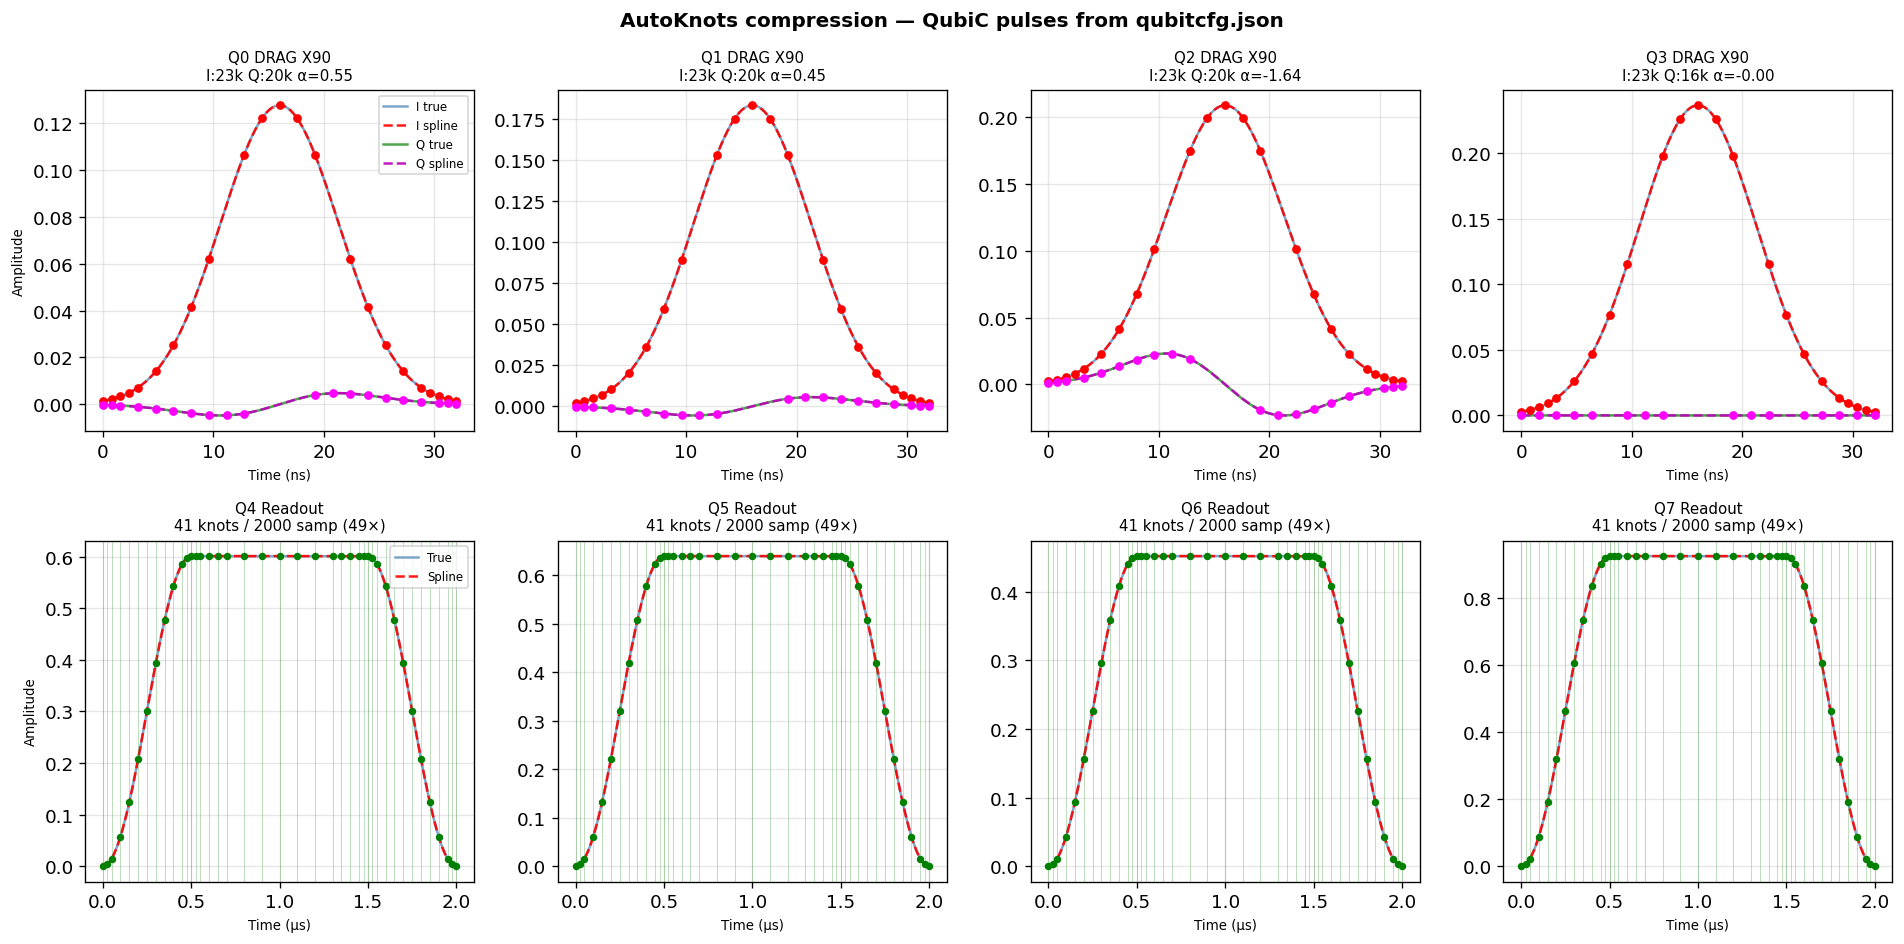

In [105]:
# Plot results
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("AutoKnots compression — QubiC pulses from qubitcfg.json",
             fontsize=12, fontweight='bold')

qubit_list = ['Q0','Q1','Q2','Q3','Q4','Q5','Q6','Q7']

for col, qn in enumerate(qubit_list[:4]):
    # Row 0: DRAG I channel
    p = drag_params[qn]
    t_sig, I_sig, Q_sig = make_drag(
        p['twidth'], p['alpha'], p['sigmas'], p['delta'], p['amp']
    )
    res_I = drag_results[qn]['I']
    res_Q = drag_results[qn]['Q']

    ax = axes[0, col]
    ax.plot(t_sig*1e9, I_sig,          'steelblue', lw=1.5, alpha=0.7, label='I true')
    ax.plot(t_sig*1e9, res_I.evaluate(t_sig), 'r--', lw=1.5, alpha=0.9, label='I spline')
    ax.plot(t_sig*1e9, Q_sig,          'green',     lw=1.5, alpha=0.7, label='Q true')
    ax.plot(t_sig*1e9, res_Q.evaluate(t_sig), 'm--', lw=1.5, alpha=0.9, label='Q spline')
    ax.scatter(res_I.knots*1e9, res_I.f_at_knots, s=18, c='red',   zorder=5)
    ax.scatter(res_Q.knots*1e9, res_Q.f_at_knots, s=18, c='magenta', zorder=5)
    ax.set_title(f"{qn} DRAG X90\nI:{res_I.n_knots}k Q:{res_Q.n_knots}k "
                 f"α={p['alpha']:.2f}", fontsize=9)
    ax.set_xlabel('Time (ns)', fontsize=8)
    if col == 0:
        ax.set_ylabel('Amplitude', fontsize=8)
        ax.legend(fontsize=7)

for col, qn in enumerate(qubit_list[4:]):
    # Row 1: readout cos_edge_square
    p     = read_params[qn]
    t_sig, env_sig = make_cos_edge_square(p['twidth'], p['ramp_fraction'], p['amp'])
    res   = read_results[qn]

    ax = axes[1, col]
    ax.plot(t_sig*1e6, env_sig,            'steelblue', lw=1.5, alpha=0.7, label='True')
    ax.plot(t_sig*1e6, res.evaluate(t_sig),'r--',       lw=1.5, alpha=0.9, label='Spline')
    ylim = ax.get_ylim()
    ax.vlines(res.knots*1e6, *ylim, colors='green', alpha=0.25, lw=0.6)
    ax.scatter(res.knots*1e6, res.f_at_knots, s=12, c='green', zorder=5)
    ax.set_ylim(ylim)
    q_full = qubit_list[4+col]
    ax.set_title(f"{q_full} Readout\n{res.n_knots} knots / 2000 samp "
                 f"({2000/res.n_knots:.0f}×)", fontsize=9)
    ax.set_xlabel('Time (µs)', fontsize=8)
    if col == 0:
        ax.set_ylabel('Amplitude', fontsize=8)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [109]:
print("=" * 68)
print("Summary — AutoKnots compression of QubiC AQT pulses")
print("=" * 68)

print(f"\n{'Pulse type':<30} {'Knots':>7} {'Segs':>6} "
      f"{'DDR/ch':>9} {'Raw':>8} {'Ratio':>8}")
print("─" * 68)

# DRAG per qubit
for qn in qubit_list:
    p   = drag_params[qn]
    rI  = drag_results[qn]['I']
    rQ  = drag_results[qn]['Q']
    raw = int(p['twidth'] * FS)
    # Combined: I+Q share the same twidth, could share knot union
    union_knots = len(np.unique(np.concatenate([rI.knots, rQ.knots])))
    label = f"  {qn} DRAG X90  I+Q union"
    print(f"{label:<32} {union_knots:>7} {union_knots-1:>6} "
          f"{(union_knots-1)*32*2:>9}  {raw*2:>8} "
          f"{raw*2/((union_knots-1)*2):>7.1f}×")

print()
# Readout per qubit
for qn in qubit_list:
    p   = read_params[qn]
    res = read_results[qn]
    raw = int(p['twidth'] * FS)
    label = f"  {qn} Readout cos_edge_sq"
    print(f"{label:<32} {res.n_knots:>7} {res.n_segments:>6} "
          f"{res.n_segments*32:>9}  {raw:>8} "
          f"{raw/res.n_knots:>7.1f}×")

Summary — AutoKnots compression of QubiC AQT pulses

Pulse type                       Knots   Segs    DDR/ch      Raw    Ratio
────────────────────────────────────────────────────────────────────
  Q0 DRAG X90  I+Q union              25     24      1536        64     1.3×
  Q1 DRAG X90  I+Q union              25     24      1536        64     1.3×
  Q2 DRAG X90  I+Q union              25     24      1536        64     1.3×
  Q3 DRAG X90  I+Q union              25     24      1536        64     1.3×
  Q4 DRAG X90  I+Q union              25     24      1536        64     1.3×
  Q5 DRAG X90  I+Q union              25     24      1536        64     1.3×
  Q6 DRAG X90  I+Q union              25     24      1536        64     1.3×
  Q7 DRAG X90  I+Q union              25     24      1536        64     1.3×

  Q0 Readout cos_edge_sq              41     40      1280      2000    48.8×
  Q1 Readout cos_edge_sq              41     40      1280      2000    48.8×
  Q2 Readout cos_edge_sq         

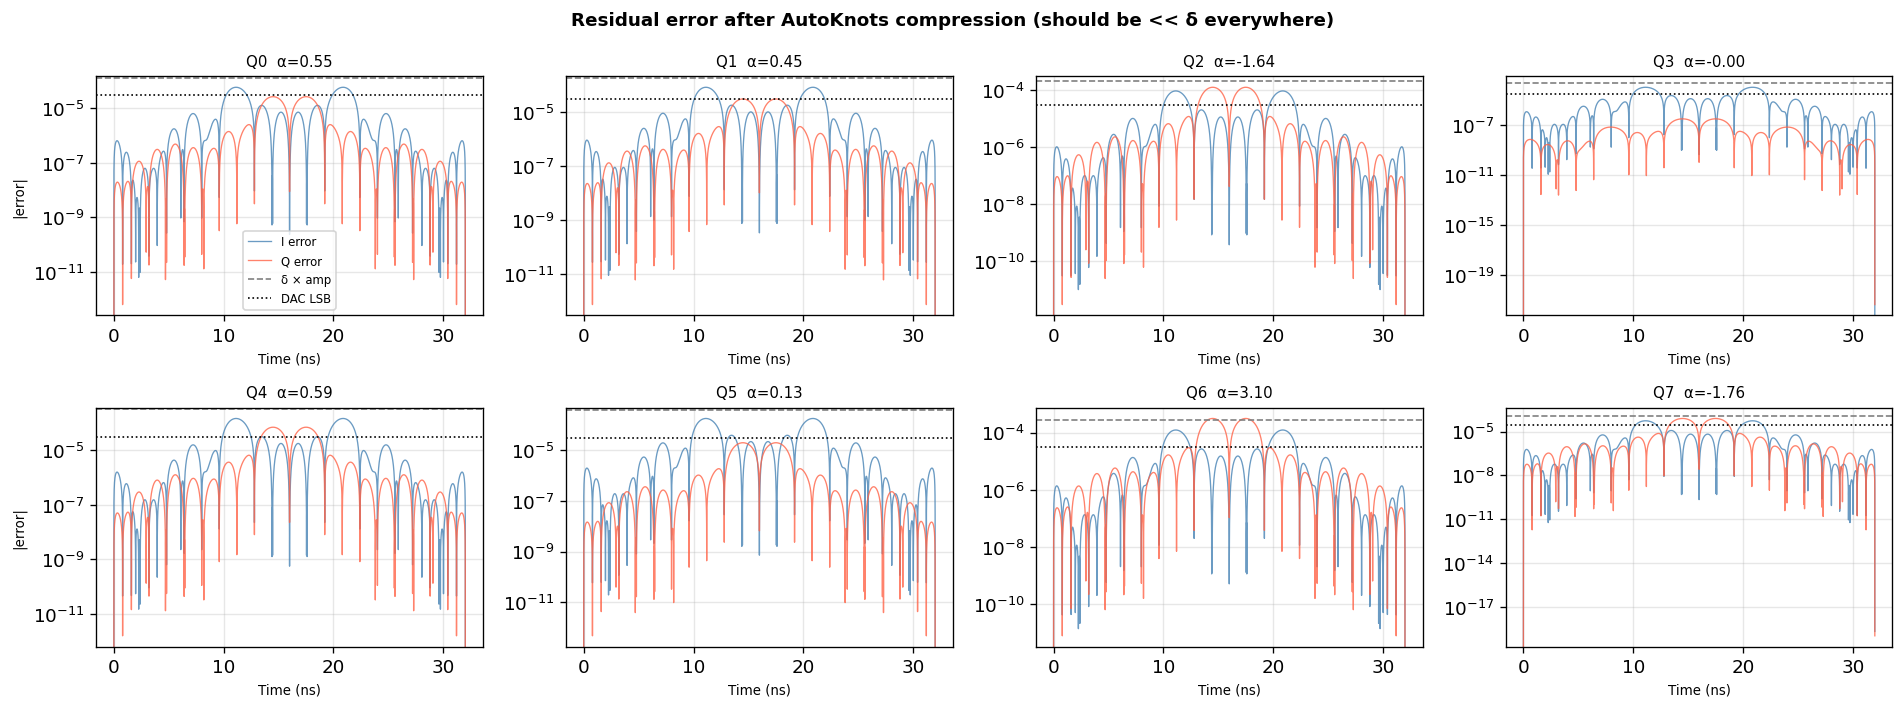


Max errors across all qubits:
  Qubit     Max I err    Max Q err      DAC LSB
  ────────────────────────────────────────────
  Q0        5.781e-05    2.616e-05    3.052e-05
  Q1        8.310e-05    3.067e-05    3.052e-05
  Q2        9.470e-05    1.274e-04    3.052e-05
  Q3        1.071e-04    3.163e-07    3.052e-05
  Q4        1.409e-04    6.761e-05    3.052e-05
  Q5        1.776e-04    1.959e-05    3.052e-05
  Q6        1.238e-04    3.139e-04    3.052e-05
  Q7        5.511e-05    7.944e-05    3.052e-05


In [111]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle("Residual error after AutoKnots compression (should be << δ everywhere)",
             fontsize=11, fontweight='bold')

for col, qn in enumerate(qubit_list):
    p = drag_params[qn]
    t_sig, I_sig, Q_sig = make_drag(
        p['twidth'], p['alpha'], p['sigmas'], p['delta'], p['amp']
    )
    res_I = drag_results[qn]['I']
    res_Q = drag_results[qn]['Q']

    err_I = np.abs(I_sig - res_I.evaluate(t_sig))
    err_Q = np.abs(Q_sig - res_Q.evaluate(t_sig))

    ax = axes[0 if col < 4 else 1, col % 4]
    ax.semilogy(t_sig*1e9, err_I, 'steelblue', lw=0.8, alpha=0.8, label='I error')
    ax.semilogy(t_sig*1e9, err_Q, 'tomato',    lw=0.8, alpha=0.8, label='Q error')
    ax.axhline(DELTA * p['amp'],   color='gray', ls='--', lw=1, label='δ × amp')
    ax.axhline(EPS_DAC, color='black', ls=':', lw=1, label='DAC LSB')
    ax.set_title(f"{qn}  α={p['alpha']:.2f}", fontsize=9)
    ax.set_xlabel('Time (ns)', fontsize=8)
    if col % 4 == 0:
        ax.set_ylabel('|error|', fontsize=8)
    if col == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("\nMax errors across all qubits:")
print(f"  {'Qubit':<6} {'Max I err':>12} {'Max Q err':>12} {'DAC LSB':>12}")
print("  " + "─"*44)
for qn in qubit_list:
    p = drag_params[qn]
    t_sig, I_sig, Q_sig = make_drag(
        p['twidth'], p['alpha'], p['sigmas'], p['delta'], p['amp']
    )
    eI = float(np.max(np.abs(I_sig - drag_results[qn]['I'].evaluate(t_sig))))
    eQ = float(np.max(np.abs(Q_sig - drag_results[qn]['Q'].evaluate(t_sig))))
    print(f"  {qn:<6} {eI:>12.3e} {eQ:>12.3e} {EPS_DAC:>12.3e}")